In [1]:
import numpy as np

def softmax(z):
    z = z - np.max(z)        # numerical stability
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

def cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.sum(y_true * np.log(y_pred))

# input with 4 features
x = np.array([2.0, 1.5, -1.0, 0.5])

# 3 classes
W = np.array([
    [ 0.8,  0.2, 0.1, 0.4],
    [-0.5,  0.7, 0.2, 0.3],
    [ 0.1, -0.3, 0.6, 0.2]
])

b = np.array([0.1, 0.2, -0.1])

# logits
z = W @ x + b

# probabilities
p = softmax(z)

print("Logits:", z)
print("Probabilities:", p)

predicted_class = np.argmax(p)

print("Predicted class:", predicted_class)
y_true = np.array([0, 1, 0])
print(f"Cross entropy loss with y_true={y_true}:{cross_entropy(y_true, p)}")
y_true = np.array([1, 0, 0])
print(f"Cross entropy loss with y_true={y_true}:{cross_entropy(y_true, p)}")


Logits: [ 2.1   0.2  -0.85]
Probabilities: [0.83201021 0.12444262 0.04354717]
Predicted class: 0
Cross entropy loss with y_true=[0 1 0]:2.0839105646279372
Cross entropy loss with y_true=[1 0 0]:0.18391056462793703


In [2]:
"""
Linear Network Classification with Cross-Entropy Loss
======================================================
A complete from-scratch example using only NumPy.
Network: Input(64) -> Linear(4) -> Softmax -> CrossEntropy
         (single layer — no hidden layer, no activation)
"""

import numpy as np

# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Constants ─────────────────────────────────────────────────────────────────
CLASSES   = ["Circle", "Cross", "Triangle", "Square"]
N_CLASSES = 4
IMG_SIZE  = 8                       # 8×8 pixels
INPUT_DIM = IMG_SIZE * IMG_SIZE     # 64
LR        = 0.05
EPOCHS    = 200


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  DATASET  —  synthetic 8×8 shape images
# ═══════════════════════════════════════════════════════════════════════════════

def make_image(class_idx: int, noise: float = 0.1) -> np.ndarray:
    """Return a flat 64-d vector for one shape (values in [-1, 1])."""
    img = np.zeros((8, 8))

    if class_idx == 0:          # Circle — ring of pixels
        for x, y in [(2,0),(3,0),(4,0),(5,0),(1,1),(6,1),(0,2),(7,2),
                     (0,3),(7,3),(0,4),(7,4),(1,5),(6,5),(2,6),(3,6),(4,6),(5,6)]:
            img[y, x] = 1.0

    elif class_idx == 1:        # Cross — two diagonals
        for i in range(8):
            img[i, i] = 1.0
            img[i, 7 - i] = 1.0

    elif class_idx == 2:        # Triangle — upper half-triangle
        for row in range(4):
            for col in range(row, 8 - row):
                img[row, col] = 1.0

    else:                       # Square — filled rectangle with border
        img[1:7, 1:7] = 1.0
        img[0, :] = img[7, :] = img[:, 0] = img[:, 7] = 1.0

    img += np.random.randn(8, 8) * noise
    img  = np.clip(img, 0, 1)
    return img.flatten() * 2 - 1            # normalise to [-1, 1]


def make_dataset(n_per_class: int = 32):
    X, y = [], []
    for c in range(N_CLASSES):
        for _ in range(n_per_class):
            X.append(make_image(c))
            y.append(c)
    X = np.array(X)                         # (N, 64)
    y = np.array(y)                         # (N,)
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]


# ═══════════════════════════════════════════════════════════════════════════════
# 2.  SOFTMAX
# ═══════════════════════════════════════════════════════════════════════════════

def softmax(z: np.ndarray) -> np.ndarray:
    """Numerically stable softmax over the last axis."""
    z_shift = z - z.max(axis=-1, keepdims=True)
    exp_z   = np.exp(z_shift)
    return exp_z / exp_z.sum(axis=-1, keepdims=True)


# ═══════════════════════════════════════════════════════════════════════════════
# 3.  LOSS FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════

def cross_entropy_loss(probs: np.ndarray, y: np.ndarray) -> float:
    """
    L = -(1/N) * Σᵢ log(p[i, yᵢ])

    probs : (N, C)  — softmax output
    y     : (N,)    — integer class labels
    """
    p_true = probs[np.arange(len(y)), y].clip(1e-9)
    return float(-np.mean(np.log(p_true)))

def cross_entropy_grad(probs: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Combined softmax + cross-entropy gradient w.r.t. logits:
        dL/dz = (probs - one_hot(y)) / N
    """
    grad = probs.copy()
    grad[np.arange(len(y)), y] -= 1
    return grad / len(y)


# ═══════════════════════════════════════════════════════════════════════════════
# 4.  NETWORK PARAMETERS  (single layer only)
# ═══════════════════════════════════════════════════════════════════════════════

def init_params():
    """Xavier initialisation for W, zeros for b."""
    W = np.random.randn(INPUT_DIM, N_CLASSES) * np.sqrt(1.0 / INPUT_DIM)
    b = np.zeros(N_CLASSES)
    return W, b


# ═══════════════════════════════════════════════════════════════════════════════
# 5.  FORWARD PASS
# ═══════════════════════════════════════════════════════════════════════════════

def forward(X: np.ndarray, W, b):
    """
    X      : (N, 64)
    logits : (N, 4)   = X @ W + b
    probs  : (N, 4)   = softmax(logits)
    """
    logits = X @ W + b          # (N, 4)
    probs  = softmax(logits)    # (N, 4)
    return probs, logits


# ═══════════════════════════════════════════════════════════════════════════════
# 6.  BACKWARD PASS
# ═══════════════════════════════════════════════════════════════════════════════

def backward(X: np.ndarray, probs: np.ndarray, y: np.ndarray):
    """
    dL/dW = Xᵀ · dL/dz        shape (64, 4)
    dL/db = Σ dL/dz            shape (4,)
    """
    dz = cross_entropy_grad(probs, y)   # (N, 4)
    dW = X.T @ dz                       # (64, 4)
    db = dz.sum(axis=0)                 # (4,)
    return dW, db


# ═══════════════════════════════════════════════════════════════════════════════
# 7.  TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════

def train():
    X_train, y_train = make_dataset(n_per_class=32)
    W, b             = init_params()

    print(f"\n{'─'*52}")
    print(f"  Single-Layer Linear Classification")
    print(f"{'─'*52}")
    print(f"  Architecture : {INPUT_DIM} → {N_CLASSES} (Softmax)")
    print(f"  Parameters   : {INPUT_DIM * N_CLASSES} weights + {N_CLASSES} biases = {INPUT_DIM*N_CLASSES + N_CLASSES} total")
    print(f"  Dataset      : {len(y_train)} samples, {N_CLASSES} classes")
    print(f"  Learning rate: {LR}")
    print(f"{'─'*52}\n")

    for epoch in range(1, EPOCHS + 1):
        probs, _  = forward(X_train, W, b)
        loss      = cross_entropy_loss(probs, y_train)
        accuracy  = (probs.argmax(axis=1) == y_train).mean()
        dW, db    = backward(X_train, probs, y_train)

        W -= LR * dW
        b -= LR * db

        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>4d}/{EPOCHS}  |  Loss: {loss:.4f}  |  Acc: {accuracy*100:.1f}%")

    return W, b


# ═══════════════════════════════════════════════════════════════════════════════
# 8.  SINGLE-SAMPLE TRACE — step-by-step cross-entropy calculation
# ═══════════════════════════════════════════════════════════════════════════════

def trace_single_sample(W, b):
    """Print every intermediate value for one sample."""
    true_class = 0                              # "Circle"
    x = make_image(true_class, noise=0.0)       # clean image, shape (64,)

    print(f"\n{'═'*52}")
    print(f"  Step-by-step trace — true class: {CLASSES[true_class]}")
    print(f"{'═'*52}")

    # Step 1 — input
    print(f"\n  [1] Input vector x ∈ ℝ⁶⁴")
    print(f"      x[:8] = {x[:8].round(3)}")

    # Step 2 — single linear layer
    logits = x @ W + b
    print(f"\n  [2] logits = Wx + b  →  shape {logits.shape}")
    for c, val in zip(CLASSES, logits):
        print(f"      {c:<10s}: {val:+.6f}")

    # Step 3 — softmax
    probs = softmax(logits[None])[0]
    exp_s = np.exp(logits - logits.max())
    print(f"\n  [3] Softmax probabilities")
    print(f"      exp(logits − max) = {exp_s.round(4)}")
    print(f"      sum               = {exp_s.sum():.6f}")
    for c, p in zip(CLASSES, probs):
        bar    = "█" * int(p * 30)
        marker = " ← true class" if c == CLASSES[true_class] else ""
        print(f"      {c:<10s}: {p:.6f}  {bar}{marker}")

    # Step 4 — cross-entropy
    p_true = probs[true_class]
    loss   = -np.log(p_true)
    print(f"\n  [4] Cross-entropy loss")
    print(f"      L = −log(p[{true_class}])")
    print(f"        = −log({p_true:.6f})")
    print(f"        = {loss:.6f} nats")

    # Step 5 — gradient
    dz = probs.copy()
    dz[true_class] -= 1
    print(f"\n  [5] Gradient dL/dz = probs − one_hot(y)")
    for c, g in zip(CLASSES, dz):
        marker = " ← (p − 1)" if c == CLASSES[true_class] else " ← (p − 0)"
        print(f"      {c:<10s}: {g:+.6f}{marker}")

    pred = probs.argmax()
    print(f"\n  Predicted: {CLASSES[pred]}  |  {'✓ Correct' if pred == true_class else '✗ Wrong'}")
    print(f"{'═'*52}\n")


# ═══════════════════════════════════════════════════════════════════════════════
# 9.  MAIN
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    W, b = train()
    trace_single_sample(W, b)


────────────────────────────────────────────────────
  Single-Layer Linear Classification
────────────────────────────────────────────────────
  Architecture : 64 → 4 (Softmax)
  Parameters   : 256 weights + 4 biases = 260 total
  Dataset      : 128 samples, 4 classes
  Learning rate: 0.05
────────────────────────────────────────────────────

  Epoch    1/200  |  Loss: 1.8113  |  Acc: 25.0%
  Epoch   20/200  |  Loss: 0.0686  |  Acc: 100.0%
  Epoch   40/200  |  Loss: 0.0326  |  Acc: 100.0%
  Epoch   60/200  |  Loss: 0.0214  |  Acc: 100.0%
  Epoch   80/200  |  Loss: 0.0159  |  Acc: 100.0%
  Epoch  100/200  |  Loss: 0.0127  |  Acc: 100.0%
  Epoch  120/200  |  Loss: 0.0105  |  Acc: 100.0%
  Epoch  140/200  |  Loss: 0.0090  |  Acc: 100.0%
  Epoch  160/200  |  Loss: 0.0079  |  Acc: 100.0%
  Epoch  180/200  |  Loss: 0.0070  |  Acc: 100.0%
  Epoch  200/200  |  Loss: 0.0063  |  Acc: 100.0%

════════════════════════════════════════════════════
  Step-by-step trace — true class: Circle
═════════

In [3]:
circle=make_image(0)

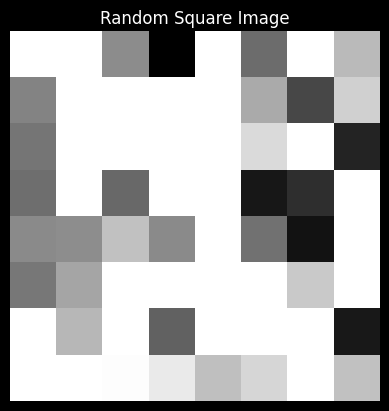

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def print_image(image_index):

    image=make_image(image_index)
    image_name=CLASSES[image_index]
    # Display image
    plt.imshow(image.reshape((8,8)), cmap="gray")
    plt.axis('off')  # hide axes
    plt.title(f"Random {image_name} Image")
    plt.show()

print_image(3)


